# System components analysis


This script covers the data analysis for each component, including their efficiency and yield. 

### Setup
First the environment is set up and plotting functyions are imported:

In [8]:
""
"  This Code is created by Daan Schat - 5169801 - TU Delft Master Student SET"
"  for the Green Village energy hub project"
""

# Setting up the environment:
import matplotlib.pyplot as plt
import random
import pandas as pd
import numpy as np
import os
import chardet

# Some variables & constants:
subfolder = "All dataframes/dataframes-1-min"
solarsubfolder = "All dataframes/dataframes-solar"

# Importing pickle files:
#DataframesToLoad = ["Battery_Current","Battery_State_Of_Charge","Battery_Power", "Electrolyser_Hydrogen_Flow_Rate"] # Please put the names of the dataframes (features) to load here
pickle_files = [os.path.splitext(f)[0] for f in os.listdir(subfolder) if f.endswith('.pkl')]

# Load all pickle files available, or just the ones we need
DataframesToLoad =  pickle_files 

for var_name in DataframesToLoad:
    globals()[var_name] = pd.read_pickle(os.path.join(subfolder, f"{var_name}.pkl"))
    print(f"Loaded {var_name} from {subfolder}")

globals()['solar_data'] = pd.read_pickle(os.path.join(solarsubfolder, "solar_data.pkl"))


LHV_H2 = 120000000 # J/kg
HHV_H2 = 142000000 # J/kg
MolarVolume = 22.414 # L/mol.
MolarMass = 2.016 # g/mol
H2Density = MolarMass/MolarVolume # g/L

# Import matplotlib.image as mpimg # Used later to export to PNG)

Loaded Temperature_Monitoring_Outdoor_Temperarture from All dataframes/dataframes-1-min
Loaded Temperature_Control_Outgoing_H2_Pipe_Heat_Tracing_Controller_Control_Signal from All dataframes/dataframes-1-min
Loaded Battery_Current from All dataframes/dataframes-1-min
Loaded Compressor_Stack_Coolant_Temperature_Out from All dataframes/dataframes-1-min
Loaded Pressure_Transmitter_Maximum_Pressure from All dataframes/dataframes-1-min
Loaded Outdoor_Convector_Outdoor_Convector_Flow from All dataframes/dataframes-1-min
Loaded Outdoor_Convector_Outdoor_Convector_Feed_Temperature from All dataframes/dataframes-1-min
Loaded Compressor_Compressor_Coolant_Temperature_In from All dataframes/dataframes-1-min
Loaded Compressor_PLC_Warning_Register from All dataframes/dataframes-1-min
Loaded Outdoor_Convector_Outdoor_Convector_Pump_Control_Signal from All dataframes/dataframes-1-min
Loaded Compressor_PLC_Yield_Output from All dataframes/dataframes-1-min
Loaded Temperature_Monitoring_Hydrogen_Cabinet

In [10]:
# Setting up plotting layout
figdim=(10, 6)
title_fontsize  = 18
label_fontsize  = 16
tick_fontsize   = 14
legend_fontsize = 14

# The following fucntions plot figures on the data and/or do some calculations.
# The functions just simply take the new pandas dataframes by their string name: E.g. 'Battery_Current'

# The fplot function simply plots a feature over time (and can take multiple features to be plotted into one figure)
def fplot(*vars):
    minval = maxval = 0
    measurement_types = set()
    plt.figure(figsize=figdim)
    for var in vars:
        if var in globals():
            data = globals()[var] # Needed to recall the data from their string name
            device_measurement_label = f"{data['device_id'].iloc[0]} - {data['measurement_id'].iloc[0]}"
            plt.plot(data['time'], data['value_float'], marker='', linestyle='-',linewidth = 3, label=var,)
            measurement_types.add(data['measurement_id'].iloc[0])

            #Determines size needed of the canvas (surely could be improved)
            if minval > min(data['value_float']):
                minval = min(data['value_float'])
            if maxval < max(data['value_float']):
                maxval = max(data['value_float'])
        else:
            print(f"Variable '{var}' not found!")

    # Fixes labeling for multiple features to be plotted in one figure
    if len(measurement_types) == 1:
        plt.ylabel(f"Measurements: ({measurement_types.pop()})", fontsize=label_fontsize)
    else:
        plt.ylabel(f"Measurements: ({', '.join(sorted(measurement_types))})", fontsize=label_fontsize)

    # Plotting settings:
    plt.xlabel('Time', fontsize=label_fontsize)
 #  plt.ylabel(f'Value {data['measurement_id']}', fontsize=label_fontsize)
    plt.xlim(min(data['time']), max(data['time']))
    plt.ylim(minval*1.2, maxval*1.2)
    plt.title('Device Measurements Over Time',fontsize=title_fontsize)
    plt.xticks(rotation=45, fontsize=tick_fontsize)
    plt.tight_layout()
    plt.legend(fontsize=legend_fontsize)
    plt.grid(True)
    plt.show()

# These functions handle integration (area under curve) For energy (W) to (kWh) and H2 flow (NL/h) to (kg & kWh)
def integrate(var):
    if var in globals():
        data = globals()[var]
        time = data['time']
        values = data['value_float']
        time_numeric = (time - time.iloc[0]).dt.total_seconds().astype(int)
        integral = np.trapz(values, time_numeric)
    else:
        print(f"Variable '{var}' not found!")

    plt.figure(figsize=figdim)
    plt.plot(time, values, label='Data')
    plt.fill_between(time, values, alpha=0.2, label=f'Integrated Area: {integral_value}')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.xlim(min(time),max(time))
    plt.title('Integrated data')
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return integral


# Called upon, this function gives a plot with integrated results of power, and gives the energy content (Pos,Neg, and cumulative)
def integrate_hr(var):
    if var in globals():
        data = globals()[var]
        time = data['time']
        values = data['value_float']
        time_numeric = (time - time.iloc[0]).dt.total_seconds().astype(int)
        
        # We seperate positive and negative data in case power can be negative and positive (Battery)
        positive_values = np.where(values > 0, values, 0)
        negative_values = np.where(values < 0, values, 0)
        kWh_pos = np.trapz(positive_values, time_numeric)/3600000 # Perform integration for positive values
        kWh_neg = np.trapz(negative_values, time_numeric)/3600000 # Perform integration for negative values
        joules = np.trapz(values, time_numeric)
        energy_kWh = joules / 3600000
    else:
        print(f"Variable '{var}' not found!")  

    plt.figure(figsize=figdim)
    plt.plot(time, values, label='Power Data')
    plt.fill_between(time, positive_values, alpha=0.2, label=f'Positive Energy (kWh): {kWh_pos:.3f}', color='green')
    plt.fill_between(time, negative_values, alpha=0.2, label=f'Negative Energy (kWh): {kWh_neg:.3f}', color='red')
    plt.xlabel('Time')
    plt.ylabel('Power [W]')
    plt.xlim(min(time),max(time))
    plt.title('Electric power and energy over time')
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return energy_kWh, kWh_pos, kWh_neg


def integrate_h2(var):
    if var in globals():
        data = globals()[var]
        time = data['time']
        values = data['value_float']
        time_numeric = (time - time.iloc[0]).dt.total_seconds().astype(int)
        positive_values = np.where(values > 0, values, 0)
        H2pos = np.trapz(values, time_numeric) # Perform integration
    else:
        print(f"Variable '{var}' not found!")  
    
    H2Prod = H2Density*H2pos/(3600*1000) # H2 flow to kg
    EnergyH2 = LHV_H2*H2Prod/(3600*1000) # H2 flow to kWh(chem) (of H2)
    plt.figure(figsize=figdim)
    plt.plot(time, values, label='Hydrogen production')
    plt.fill_between(time, positive_values, alpha=0.2, label=f'Hydrogen produced: {H2Prod:.3f} kg', color='blue')
    plt.fill_between(time, positive_values, alpha=0.2, label=f'Energy content: {EnergyH2:.3f} kWh', color='blue')

    plt.xlabel('Time')
    plt.ylabel('Hydrogen Flow [NL/h]')
    plt.xlim(min(time),max(time))
    plt.title('Hydrogen production over time')
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return H2Prod

### PV Data
First, at the beginning of the chain, the PV panels of the 24/7 energyhub will be examined. The panels consist of 12 440 Wp panels. Also, irradiance data is imported measured from the roof of the Green village officelab. the data is given in w/m2.

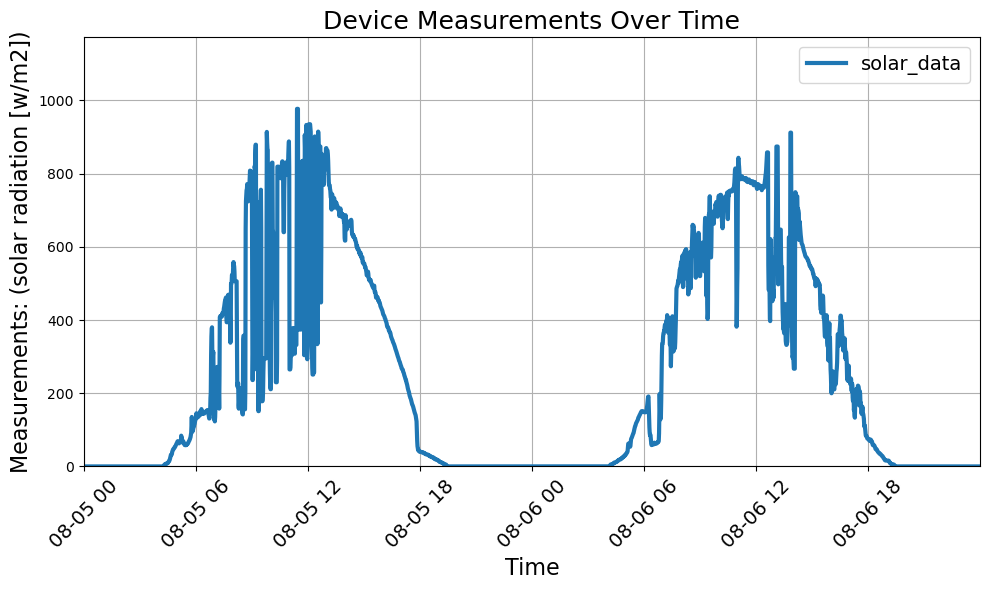

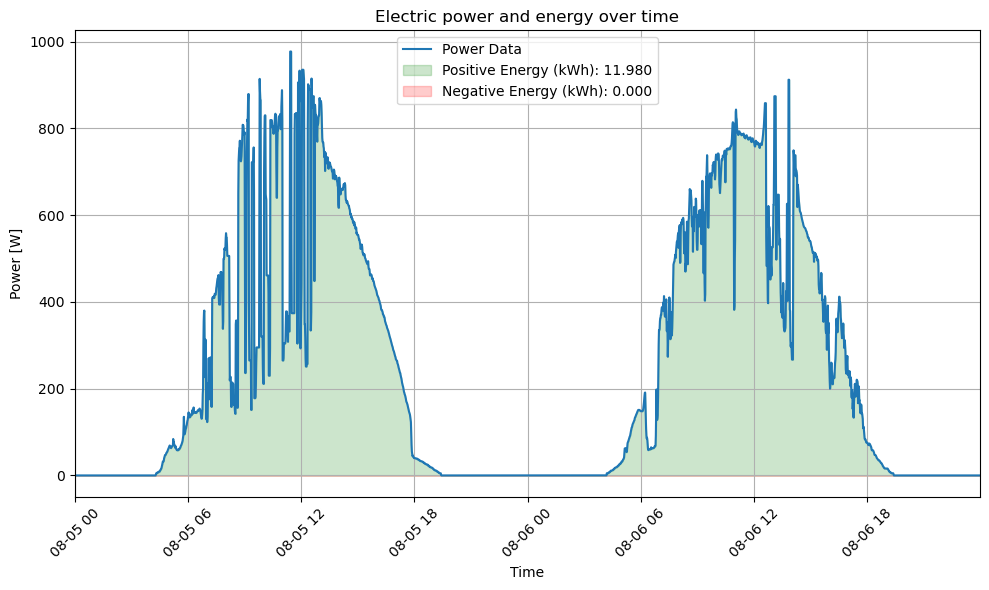

Available solar irradiance:, 287.25 kWh


In [12]:
solar_data['device_id'] = 'weatherstation'
solar_data['measurement_id'] = 'solar radiation [w/m2]'
solar_data.rename(columns={'value_int': 'value_float'}, inplace=True)

fplot('solar_data')
solarEnergy = integrate_hr('solar_data')[1] # per m2
AreaPP = 1.762*1.134 # m2/panel
solarAvailable = solarEnergy*12*AreaPP # 5340 Wp installed capacity with 445 Wp panels,so 5340/445 or 12 panels, with 
print(f"Available solar irradiance:, {solarAvailable:.2f} kWh")

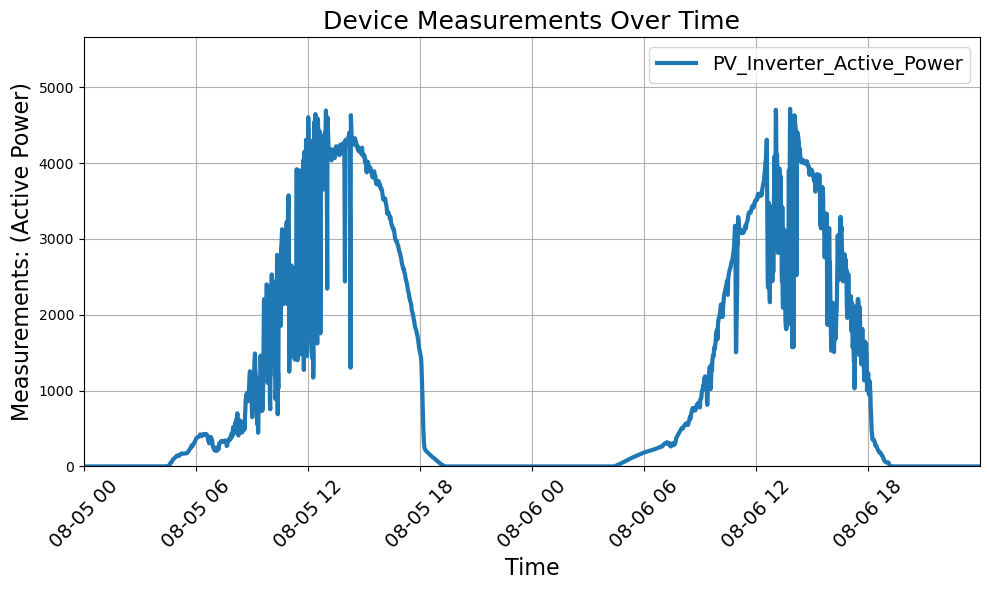

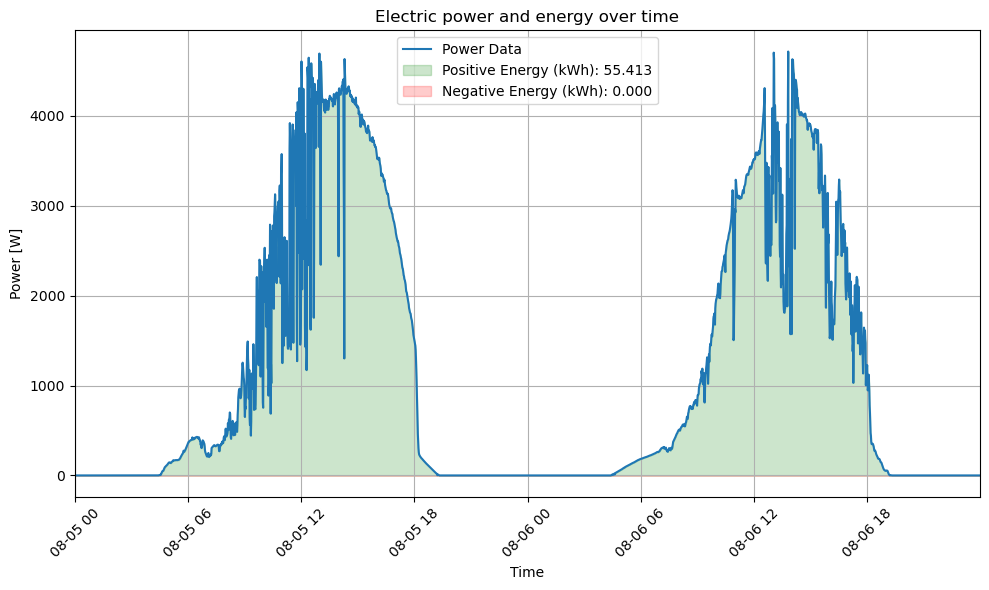

solar energy generated:, 55.41 kWh (After inverter)
solar capacity factor:, 19.29 % (Available solar power vs genereted electricity)
solar energy to the battery:, 53.20 kWh


In [7]:
fplot("PV_Inverter_Active_Power")
PVyield = integrate_hr("PV_Inverter_Active_Power")[1]

# After the inverter:
print(f"solar energy generated:, {PVyield:.2f} kWh (After inverter)")
print(f"solar capacity factor:, {100*PVyield/solarAvailable:.2f} % (Available solar power vs genereted electricity)")

# To the battery (96% effient)
print(f"solar energy to the battery:, {0.96*PVyield:.2f} kWh")


### The battery
The energy created goes to the battery, which is providing energy for a student home of 1 person. 

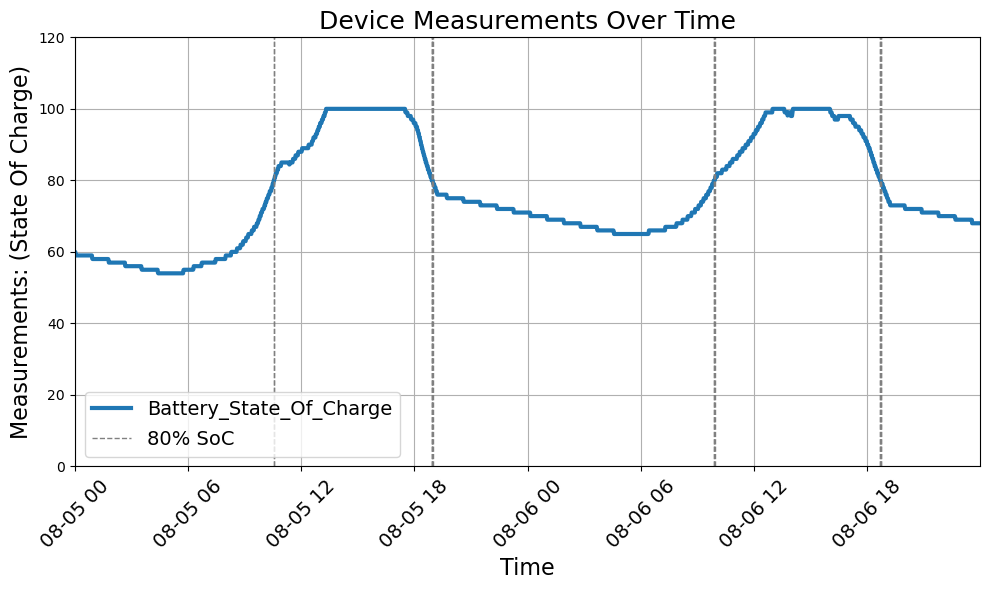

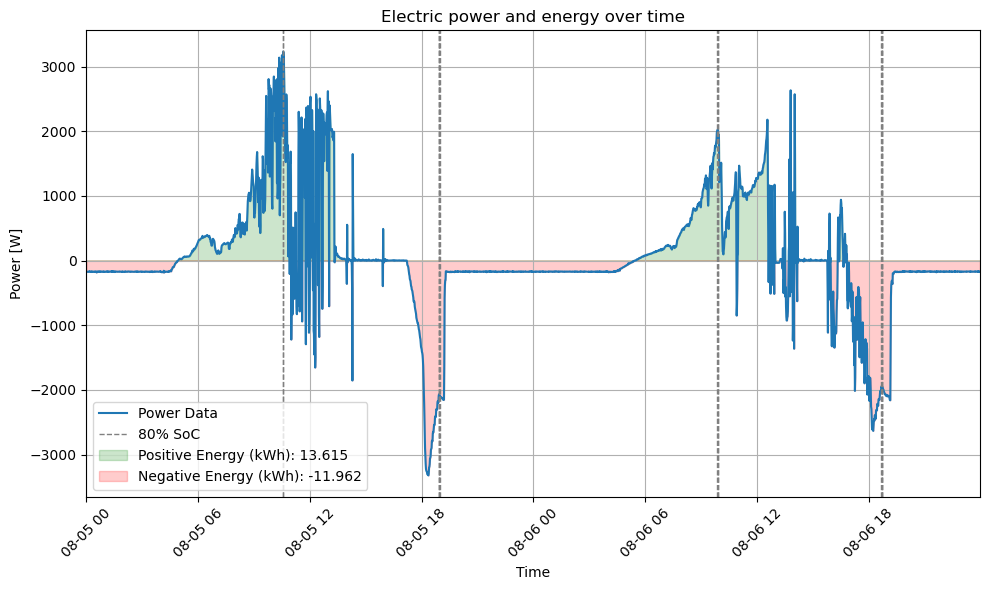

battery net energy:, 1.65 kWh
battery charged with:, 13.62 kWh
battery discharged with:, -11.96 kWh


In [9]:
def battery(ACPower, SoC):
    minval = maxval = 0
    measurement_types = set()
    plt.figure(figsize=figdim)
    data = globals()[SoC] # Needed to recall the data from their string name
    device_measurement_label = f"{data['device_id'].iloc[0]} - {data['measurement_id'].iloc[0]}"
    plt.plot(data['time'], data['value_float'], marker='', linestyle='-',linewidth = 3, label=SoC,)
    measurement_types.add(data['measurement_id'].iloc[0])

        #Determines size needed of the canvas (surely could be improved)
    if minval > min(data['value_float']):
        minval = min(data['value_float'])
    if maxval < max(data['value_float']):
        maxval = max(data['value_float'])

    # Fixes labeling for multiple features to be plotted in one figure
    if len(measurement_types) == 1:
        plt.ylabel(f"Measurements: ({measurement_types.pop()})", fontsize=label_fontsize)
    else:
        plt.ylabel(f"Measurements: ({', '.join(sorted(measurement_types))})", fontsize=label_fontsize)

    # Identify points where SoC reaches or exceeds 80%
    soc_80_points = np.where(data['value_float'] == 80)[0]
    soc_80_times = data['time'].iloc[soc_80_points]
    for t in soc_80_times:
        plt.axvline(x=t, color='grey', linestyle='--', label="80% SoC" if t == soc_80_times.iloc[0] else "", linewidth=1)
    
    # Plotting settings:
    plt.xlabel('Time', fontsize=label_fontsize)
    plt.xlim(min(data['time']), max(data['time']))
    plt.ylim(minval*1.2, maxval*1.2)
    plt.title('Device Measurements Over Time',fontsize=title_fontsize)
    plt.xticks(rotation=45, fontsize=tick_fontsize)
    plt.tight_layout()
    plt.legend(fontsize=legend_fontsize)
    plt.grid(True)
    plt.show()
    
    if ACPower in globals():
        data = globals()[ACPower]
        time = data['time']
        values = data['value_float']
        time_numeric = (time - time.iloc[0]).dt.total_seconds().astype(int)
        
        # We seperate positive and negative data in case power can be negative and positive (Battery)
        positive_values = np.where(values > 0, values, 0)
        negative_values = np.where(values < 0, values, 0)
        kWh_pos = np.trapz(positive_values, time_numeric)/3600000 # Perform integration for positive values
        kWh_neg = np.trapz(negative_values, time_numeric)/3600000 # Perform integration for negative values
        joules = np.trapz(values, time_numeric)
        energy_kWh = joules / 3600000
    else:
        print(f"Variable '{var}' not found!")  

    plt.figure(figsize=figdim)
    plt.plot(time, values, label='Power Data')
    for t in soc_80_times:
        plt.axvline(x=t, color='grey', linestyle='--', label="80% SoC" if t == soc_80_times.iloc[0] else "", linewidth=1)
    plt.fill_between(time, positive_values, alpha=0.2, label=f'Positive Energy (kWh): {kWh_pos:.3f}', color='green')
    plt.fill_between(time, negative_values, alpha=0.2, label=f'Negative Energy (kWh): {kWh_neg:.3f}', color='red')
    plt.xlabel('Time')
    plt.ylabel('Power [W]')
    plt.xlim(min(time),max(time))
    
    plt.title('Electric power and energy over time')
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    
    return energy_kWh, kWh_pos, kWh_neg


BatteryYield = battery("Battery_Power","Battery_State_Of_Charge")

print(f"battery net energy:, {BatteryYield[0]:.2f} kWh")
print(f"battery charged with:, {BatteryYield[1]:.2f} kWh")
print(f"battery discharged with:, {BatteryYield[2]:.2f} kWh")


The battery is used to provide electricity to the student home and produce hydrogen when a state of charge of 80% is reached. This is clearly visible in the AC Power out, which spikes up when the Hydrogen production is enabled at 80% SoC.

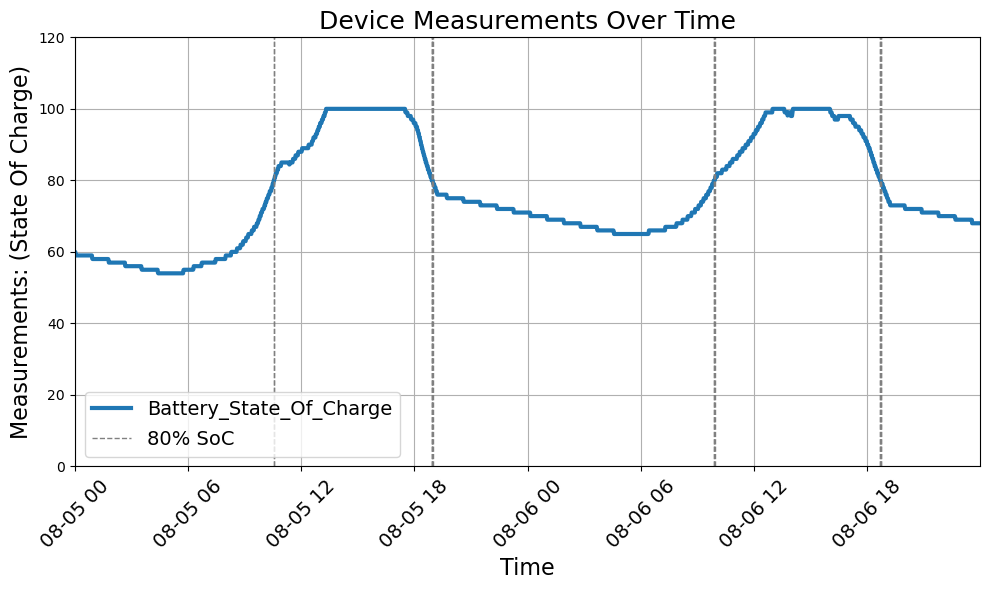

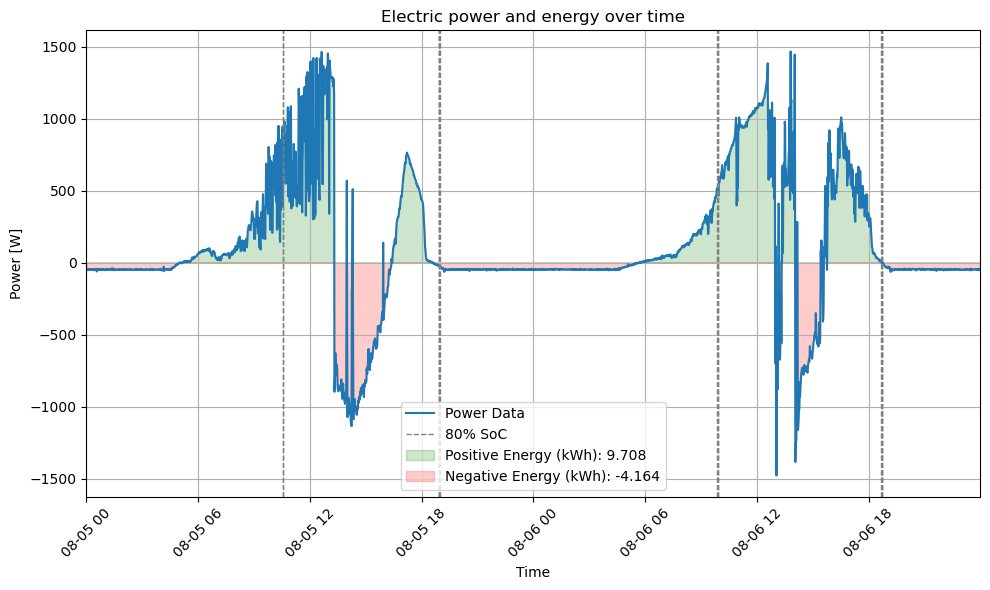

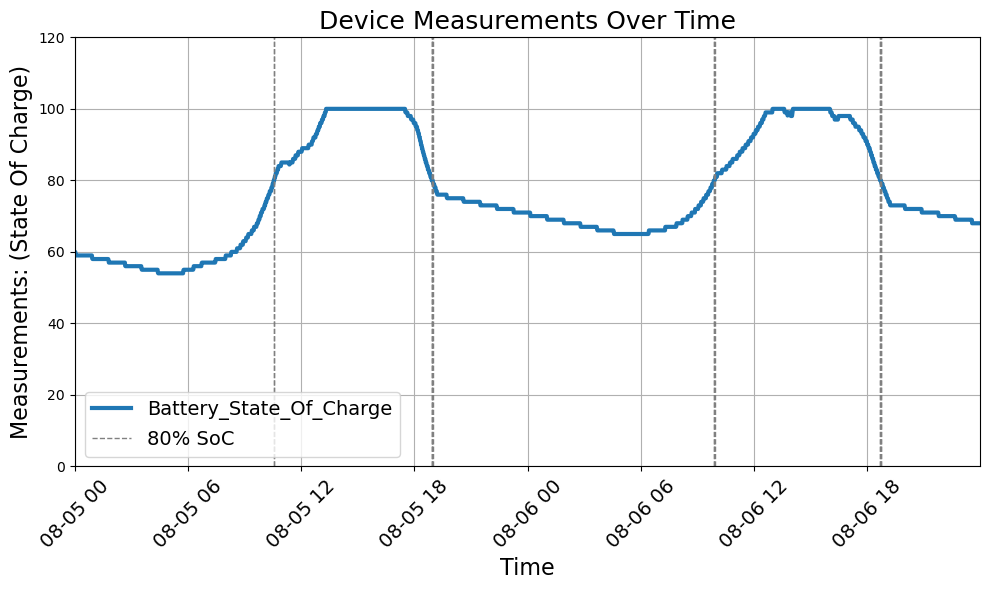

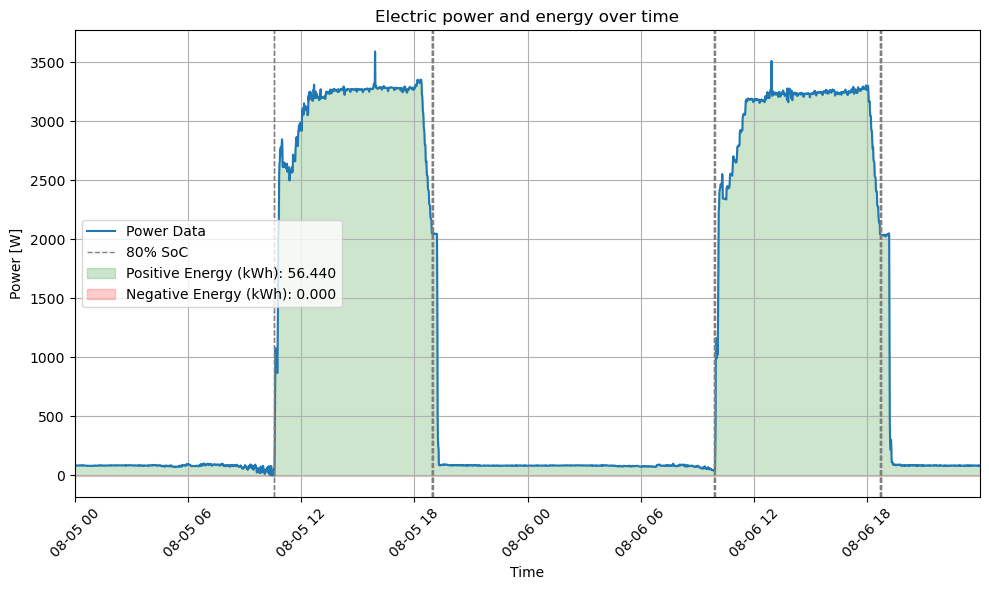

The energy used to produce hydrogen is 56.44 kWh


In [11]:
BatteryEnergyIn = battery("Battery_Inverter_AC_In_Power","Battery_State_Of_Charge")[1]
BatteryEnergyOut = battery("Battery_Inverter_AC_Out_Power","Battery_State_Of_Charge")[1]

print(f"The energy used to produce hydrogen is {BatteryEnergyOut:.2f} kWh")


Now we include the individual components Fuel cell and compressor in the energy used graph:

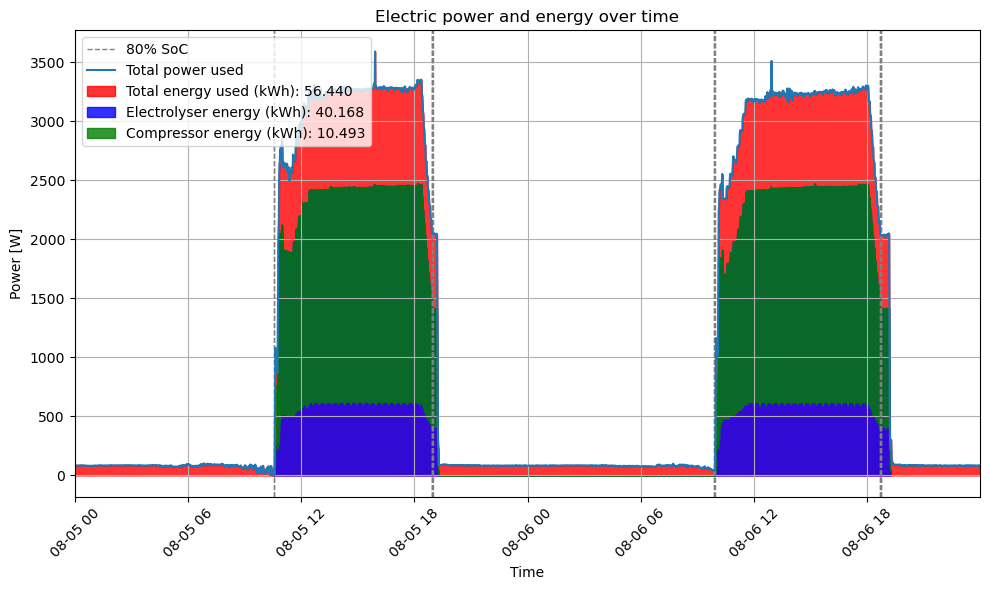

Total battery output energy: 56.44 kWh
Battery energy used by the compressor: 10.49 kWh
Battery energy used by the electrolyser: 40.17 kWh
Battery energy used other components: 5.78 kWh
Energy used by the compressor: 18.59 %
Energy used by the electrolyser: 71.17 %
Energy used by other components: 10.24 %


In [37]:
minval = maxval = 0
measurement_types = set()
plt.figure(figsize=figdim)

# First the data:
ACPowerOut = globals()["Battery_Inverter_AC_Out_Power"]
CompressorPower = globals()["Compressor_Energy_Meter_Active_Power"] 
ElectrolyserPower = globals()["Electrolyser_Energy_Meter_Active_Power"] 

# Identify points where SoC reaches or exceeds 80%
SoCdata = globals()["Battery_State_Of_Charge"] # Needed to recall the data from their string name
soc_80_points = np.where(SoCdata['value_float'] == 80)[0]
soc_80_times = SoCdata['time'].iloc[soc_80_points]
for t in soc_80_times:
    plt.axvline(x=t, color='grey', linestyle='--', label="80% SoC" if t == soc_80_times.iloc[0] else "", linewidth=1)

# Calculate timeframe (once, will be the same for all)
ElectrolyserTime = ElectrolyserPower['time']
ElectrolyserTime_numeric = (ElectrolyserTime - ElectrolyserTime.iloc[0]).dt.total_seconds().astype(int)

PowerOutTime = ACPowerOut['time']
PowerOutTime_numeric = (PowerOutTime - PowerOutTime.iloc[0]).dt.total_seconds().astype(int)


# Total Out:
values = ACPowerOut['value_float']
PowerOutValues = np.where(values > 0, values, 0)
TotACEnergy = np.trapz(PowerOutValues, PowerOutTime_numeric)/3600000 # Perform integration for positive values

# Electrolyser:
values = ElectrolyserPower['value_float']
ElectrolyserValues = np.where(values > 0, values, 0)
ElectrolyserEnergy = np.trapz(ElectrolyserValues, ElectrolyserTime_numeric)/3600000 # Perform integration for positive values

# Compressor:
values = CompressorPower['value_float']
CompressorValues = np.where(values > 0, values, 0)
CompressorEnergy = np.trapz(CompressorValues, ElectrolyserTime_numeric)/3600000 # Perform integration for positive values



plt.plot(PowerOutTime, ACPowerOut['value_float'], label='Total power used')
plt.fill_between(PowerOutTime, PowerOutValues, alpha=0.8, label=f'Total energy used (kWh): {TotACEnergy:.3f}', color='red')
plt.fill_between(ElectrolyserTime, ElectrolyserValues, alpha=0.8, label=f'Electrolyser energy (kWh): {ElectrolyserEnergy:.3f}', color='blue')
plt.fill_between(ElectrolyserTime, CompressorValues, ElectrolyserValues, alpha=0.8, label=f'Compressor energy (kWh): {CompressorEnergy:.3f}', color='green')

plt.xlabel('Time')
plt.ylabel('Power [W]')
plt.xlim(min(ACPowerOut['time']),max(ACPowerOut['time']))
plt.title('Electric power and energy over time')
plt.legend(loc="upper left")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.savefig("figures/Electrolyser report/Energyflows.png")
plt.show()

    

print(f"Total battery output energy: {TotACEnergy:.2f} kWh")
print(f"Battery energy used by the compressor: {CompressorEnergy:.2f} kWh")
print(f"Battery energy used by the electrolyser: {ElectrolyserEnergy:.2f} kWh")
print(f"Battery energy used other components: {TotACEnergy-CompressorEnergy-ElectrolyserEnergy:.2f} kWh")

print(f"Energy used by the compressor: {100*CompressorEnergy/TotACEnergy:.2f} %")
print(f"Energy used by the electrolyser: {100*ElectrolyserEnergy/TotACEnergy:.2f} %")
print(f"Energy used by other components: {100*(1-(CompressorEnergy+ElectrolyserEnergy)/TotACEnergy):.2f} %")


### Hydrogen production
Of course, the components above don't waste electricity: they use it to produce hydrogen. Below the hydrogen production is shown and calculated.

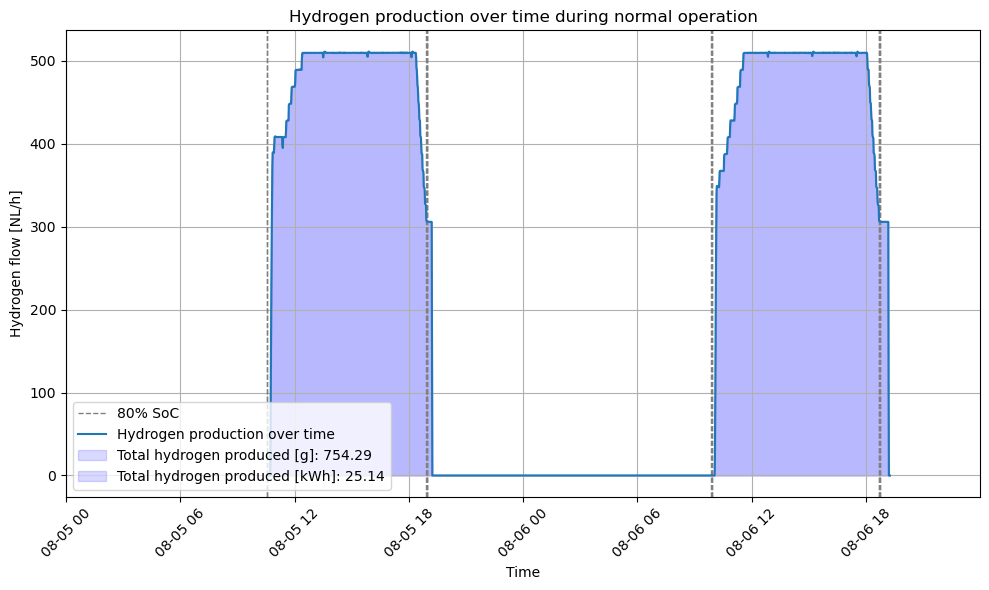

Total hydrogen production: 25.14 kWh
Efficiency from battery to hydrogen: 44.55 %


In [45]:
minval = maxval = 0
measurement_types = set()
plt.figure(figsize=figdim)

# First the data:
HydrogenProduction = globals()["Electrolyser_Hydrogen_Flow_Rate"] 
SoCdata = globals()["Battery_State_Of_Charge"] # Needed to recall the data from their string name


# Identify points where SoC reaches or exceeds 80%
soc_80_points = np.where(SoCdata['value_float'] == 80)[0]
soc_80_times = SoCdata['time'].iloc[soc_80_points]
for t in soc_80_times:
    plt.axvline(x=t, color='grey', linestyle='--', label="80% SoC" if t == soc_80_times.iloc[0] else "", linewidth=1)

time = HydrogenProduction['time']
Time_numeric = (time - time.iloc[0]).dt.total_seconds().astype(int)

# Total Out:
values = HydrogenProduction['value_float']
HydrogenProductionValues = np.where(values > 0, values, 0)
TotHydrogenProduction = np.trapz(HydrogenProductionValues, Time_numeric)
H2Prod = H2Density*TotHydrogenProduction/(3600*1000) # H2 flow to kg
EnergyH2 = LHV_H2*H2Prod/(3600*1000) # H2 flow to kWh(chem) (of H2)


plt.plot(time, HydrogenProduction['value_float'], label='Hydrogen production over time')
plt.fill_between(time, HydrogenProductionValues, alpha=0.15, label=f'Total hydrogen produced [g]: {1000*H2Prod:.2f}', color='blue')
plt.fill_between(time, HydrogenProductionValues, alpha=0.15, label=f'Total hydrogen produced [kWh]: {EnergyH2:.2f}', color='blue')

plt.xlabel('Time')
plt.ylabel('Hydrogen flow [NL/h]')
plt.xlim(min(ACPowerOut['time']),max(ACPowerOut['time']))
plt.title('Hydrogen production over time during normal operation')
plt.legend(loc = 'lower left')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.savefig("figures/Electrolyser report/HydrogenFlowNormal.png")
plt.show()

Eff_Elec_H2 = EnergyH2/TotACEnergy

print(f"Total hydrogen production: {EnergyH2:.2f} kWh")
print(f"Efficiency from battery to hydrogen: {100*Eff_Elec_H2:.2f} %")


#### From the datasheet: The electrolyser is rated for an output of 500NL/h, with an operative power consumption of 2400 W.

In [47]:
# Constants
H2EnergyPerKg = 33.6  # kWh per kilogram of hydrogen
MolarMassH2 = 2.016  # grams per mole
gasConst = 22.414  # liters per mole at STP (Standard Temperature and Pressure)

H2Rate = 500  # NL/h
H2Mol = H2Rate / gasConst # mol H2
H2Mass = H2Mol * MolarMassH2 / 1000  # kg H2

H2Energy = H2Mass * H2EnergyPerKg

# Output the result
print(f"Energy produced from {H2Rate} NL/h of hydrogen: {H2Energy:.2f} [kWh]")
print(f"Energy produced from {H2Rate} NL/h of hydrogen: {24*H2Energy:.2f} [kWh/day]")

Energy produced from 500 NL/h of hydrogen: 1.51 [kWh]
Energy produced from 500 NL/h of hydrogen: 36.27 [kWh/day]


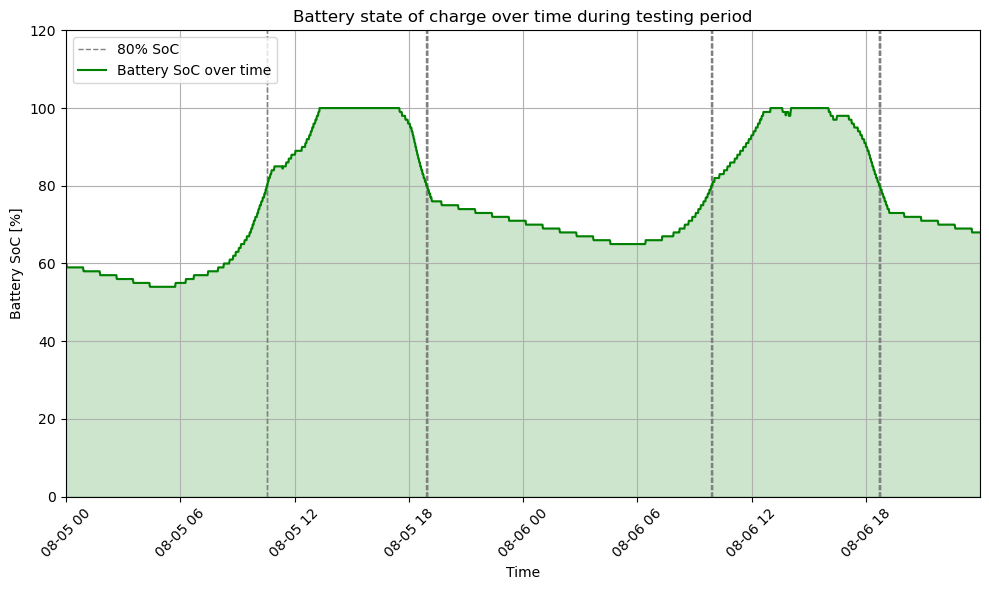

In [43]:
# Battery 
minval = maxval = 0
measurement_types = set()
plt.figure(figsize=figdim)

# First the data:
SoCdata = globals()["Battery_State_Of_Charge"] # Needed to recall the data from their string name

time = SoCdata['time']
Time_numeric = (time - time.iloc[0]).dt.total_seconds().astype(int)



# Identify points where SoC reaches or exceeds 80%
soc_80_points = np.where(SoCdata['value_float'] == 80)[0]
soc_80_times = SoCdata['time'].iloc[soc_80_points]
for t in soc_80_times:
    plt.axvline(x=t, color='grey', linestyle='--', label="80% SoC" if t == soc_80_times.iloc[0] else "", linewidth=1)


plt.plot(time, SoCdata['value_float'], label='Battery SoC over time', color = 'green')
plt.fill_between(time, SoCdata['value_float'], alpha=0.2, color='green')

plt.xlabel('Time')
plt.ylabel('Battery SoC [%]')
plt.xlim(min(SoCdata['time']),max(SoCdata['time']))
plt.ylim(0,max(SoCdata['value_float']*1.2))

plt.title('Battery state of charge over time during testing period')
plt.legend(loc = 'upper left')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.savefig("figures/Electrolyser report/BatterySoC.png")
plt.show()

### Fuel Cell efficiency
As seen in the section above, hydrogen is stored at roughly 44.55 % efficiency (battery to H2). Though, this is not how the energy is used. The hydrogen energy is converted back from chemical to electrical energy by means of fuel cell. For the selected period, no fuel cell data is present, so this cannot be examined directly.

In [24]:
# From grafana;
Hydrogen_In_Flow_min = 24.9 # NL/min
Hydrogen_In_Flow = Hydrogen_In_Flow_min*60 # NL/h
EnergyOut = 1.8 # kWh
  
H2Prod = H2Density*Hydrogen_In_Flow/1000 # H2 flow to kg
EnergyH2 = LHV_H2*H2Prod/(3600*1000) # H2 flow to kWh(chem) (of H2)
Eff_H2_Elec = EnergyOut/EnergyH2

print(f"Fuel cell efficiency: {100*Eff_H2_Elec:.2f} %")
print(f"H2 circle efficiency: {100*Eff_H2_Elec*Eff_Elec_H2:.2f} %")


Fuel cell efficiency: 40.19 %
H2 circle efficiency: 17.90 %
